<a href="https://colab.research.google.com/github/Ferarenas14/Investigaci-n-de-operaciones-/blob/main/Tutorial_networkx_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<h1><font color="#bb34e3"><b>TUTORIAL NETWORKX 1</b></font></h1>


En este tutorial describe la solución en python de tres problemas de redes:
**Árbol de expansión mínima, ruta más corta y flujo máximo**.
Basado en la documentación de [Networkx](https://networkx.org/en/)

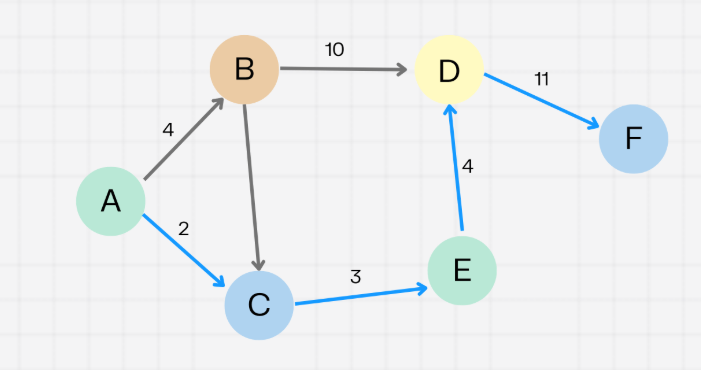

#<font color= "#d06fed"> 1. *Árbol de expansión mínima*



El algoritmo de árbol de expansión mínima enlaza los nodos de una red, en forma directa o indirecta, minimizando la longitud entre sus nodos. Los pasos del procedimiento son los siguientes. Sea $N = \{1, 2, \dots, n\}$
 el conjunto de nodos de la red, y se definen  


*   $c_k=$ Conjunto de nodos que se han conectado en forma permanente en la iteración k
*   $\overline{c_k}$ Conjunto de nodos que todavía se deben conectar en forma permanente

**Paso 0.** El conjunto $c_0= \emptyset$ y $\overline{c_0}= N$


**Paso 1.** Comenzar con cualquier nodo en el conjunto $\overline{c_0}$ no conectado (o “inconexo”), e igualar $c_1=\{i\}$, con lo que $\overline{c_1}= n- \{i\}$. Igualar K=2

**Paso genenral k.** Seleccionar un nodo $j^*$ en el conjunto no conectado $\overline{c}_{k-1}$ que produzca el arco más corto a un nodo, en el conjunto conectado $c_{k-1}$  Enlazar a $j^*$ en forma permanente con $c_{k-1}$ y sacarlo de $\overline{c}_{k-1}$  esto es

$c_k = c_{k-1} + \{j^*\}, \overline{c}_k = \overline{c}_{k-1} - \{j^*\}$

Si el conjunto $\overline{c_k}$ de nodos no conectados es vacío, detenerse. En cualquier otro caso k=k+1  y repetir el paso.


**Ejemplo:**

Use la siguiente red para calcular su árbol de expansión mínima

Nota: considerar la versión no dirigida de la red

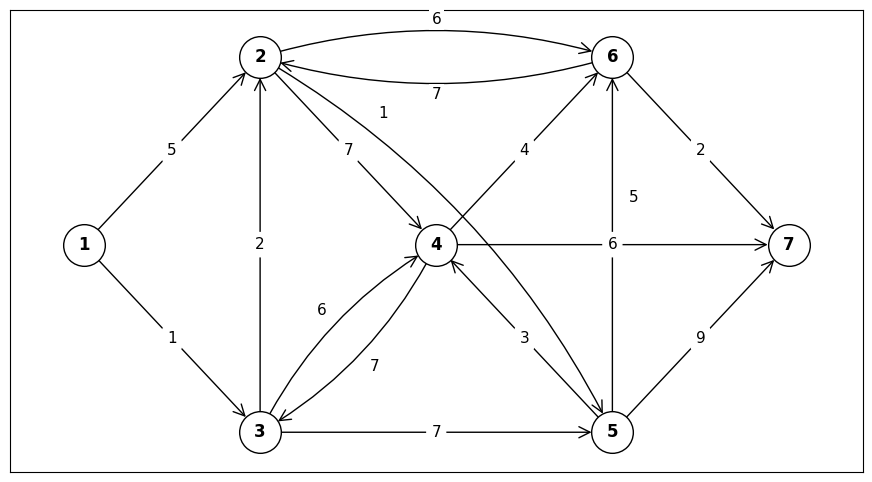

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph() # Para graficar red dirigidas

# dibujar ramas rectas
straight_edges = {
    (1, 2): 5, (1, 3): 1, (3, 2): 2, (3, 5): 7,
    (2, 4): 7, (4, 6): 4, (4, 7): 6, (5, 4): 3, (5, 7): 9,
    (6, 7): 2
}
# dibujar ramas curvas hacia la derecha e izquierda
curved_edges_left = {(6, 2): 7, (4, 3): 7, (2, 5): 1}
curved_edges_right = {(2, 6): 6, (3, 4): 6}

# función de NetworkX que recibe como una lista de tuplas y las agrega a la grafica G
G.add_edge(5, 6)
G.add_edges_from(list(straight_edges.keys()) + list(curved_edges_left.keys()) + list(curved_edges_right.keys()))

#Posiciones de los nodos
pos = {1: (0, 1), 2: (1, 2), 3: (1, 0), 4: (2, 1), 5: (3, 0), 6: (3, 2), 7: (4, 1)}
plt.figure(figsize=(11, 6)) #para dibujar los datos

# dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color='white', edgecolors='black', node_size=900)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold') #pone los numeros a los nodos

# dibujar flechas en las ramas
nx.draw_networkx_edges(G, pos, edgelist=list(straight_edges.keys()) + [(5, 6)], arrowstyle='->', arrowsize=20, node_size=900)
nx.draw_networkx_edges(G, pos, edgelist=curved_edges_left.keys(), arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.15', node_size=900)
nx.draw_networkx_edges(G, pos, edgelist=curved_edges_right.keys(), arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.15', node_size=900)

# Para poner las distancias de manera recta
nx.draw_networkx_edge_labels(G, pos, edge_labels=straight_edges, font_size=11, rotate=False)

# distancias de las ramas curvas
custom_labels = {
    (2, 6): (2.0, 2.2),
    (6, 2): (2.0, 1.8),
    (3, 4): (1.35, 0.65),
    (4, 3): (1.65, 0.35),
    (2, 5): (1.7, 1.7),
    (5, 6): (3.12, 1.25)
}

#esta funcion ayuda a poner las distancias en la posicion correcta para que no se encimen
for (u, v), (x, y) in custom_labels.items():
    weight = curved_edges_left.get((u,v)) or curved_edges_right.get((u,v)) or (5 if (u,v) == (5,6) else None)
    plt.text(x, y, str(weight), fontsize=11, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2))
# bbox=dict... pone un fondo blanco atrás del número para que tape la rama y el número se vea bien

plt.show()


**Solución:**

In [ ]:
import networkx as nx

G = nx.Graph() # Para graficar la red no dirigida

# lista de ramas (origen, destino, distancia)
# Nota: para los nodos con doble rama elegimos la que tenga la distancia menor
ramas = [
    (1, 2, 5), (1, 3, 1), (2, 3, 2), (2, 4, 7), (2, 5, 1), (2, 6, 6),
    (3, 4, 6), (3, 5, 7), (4, 5, 3), (4, 6, 4), (4, 7, 6), (5, 6, 5),
    (5, 7, 9), (6, 7, 2)
]

#añadir las ramas a la grafica
G.add_weighted_edges_from(ramas)

# función de NetworkX para calcular el Árbol de Expansión Mínima
mst = nx.minimum_spanning_tree(G)

#Imprimir resultados
print("--- Ramas del Árbol de Expansión Mínima ---")
for u, v, data in mst.edges(data=True):
    print(f"Rama ({u} - {v}) | distancia: {data['weight']}")

dis_total = mst.size(weight='weight')
print(f"\nDistancia total: {int(dis_total)}")


--- Ramas del Árbol de Expansión Mínima ---
Rama (1 - 3) | distancia: 1
Rama (2 - 5) | distancia: 1
Rama (2 - 3) | distancia: 2
Rama (4 - 5) | distancia: 3
Rama (4 - 6) | distancia: 4
Rama (6 - 7) | distancia: 2

Distancia total: 13


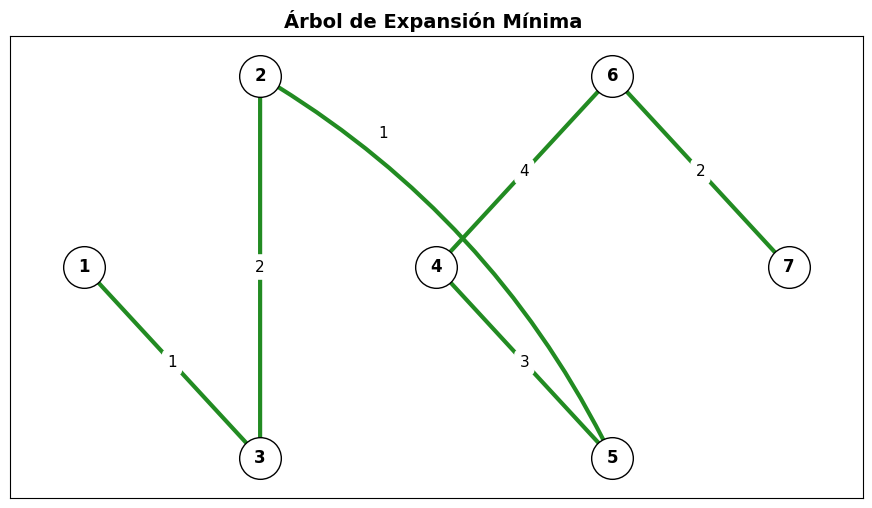

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

# ramas del árbol de expanción mínima
straight_mst = {(1, 3): 1, (3, 2): 2, (5, 4): 3, (4, 6): 4, (6, 7): 2}
curved_left_mst = {(2, 5): 1}

G.add_edges_from(list(straight_mst.keys()) + list(curved_left_mst.keys()))

#posición de los nodos
pos = {1: (0, 1), 2: (1, 2), 3: (1, 0), 4: (2, 1), 5: (3, 0), 6: (3, 2), 7: (4, 1)}
plt.figure(figsize=(11, 6))

# dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color='white', edgecolors='black', node_size=900)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# dibujar ramas
nx.draw_networkx_edges(G, pos, edgelist=list(straight_mst.keys()), arrowstyle='-',
                       node_size=900, edge_color='forestgreen', width=3)

nx.draw_networkx_edges(G, pos, edgelist=list(curved_left_mst.keys()), arrowstyle='-',
                       connectionstyle='arc3,rad=-0.15', node_size=900,
                       edge_color='forestgreen', width=3)

# dibujar las distancias en las ramas rectas
nx.draw_networkx_edge_labels(G, pos, edge_labels=straight_mst, font_size=11, rotate=False)

# dibujar la distancia en la rama curva
plt.text(1.7, 1.7, "1", fontsize=11, ha='center', va='center',
         bbox=dict(facecolor='white', edgecolor='none', pad=2))

plt.title("Árbol de Expansión Mínima ", fontsize=14, fontweight='bold')
plt.show()


Por lo tanto la distancia total  del árbol de expanción mínima es 13

#<font color= "#d06fed"> 2. *Ruta más corta*

Considere una red conexa y no dirigida con dos nodos especiales, llamados **origen** y **destino**. A cada ligadura se asocia una distancia no negativa. El objetivo es encontrar la ruta más corta —la trayectoria de mínima distancia total— del origen al destino.

**Algoritmo**

**Objetivo de la n-ésima iteración:** Encontrar el n-ésimo nodo más cercano al origen. Repetir para n = 1, 2, ..., hasta que el n-ésimo nodo más cercano sea el destino.

**Datos de la n-ésima iteración:** \(n-1\) nodos más cercanos al origen —encontrados en iteraciones previas—, incluido su ruta más corta y la distancia desde el origen (estos son nodos resueltos; el resto son nodos no resueltos).

**Candidato a n-ésimo nodo más cercano:** Cada nodo no resuelto con conexión directa a uno o más nodos resueltos. Tomar el nodo no resuelto que tiene la ligadura más corta (los empates proporcionan candidatos adicionales).

**Cálculo del n-ésimo nodo más cercano:** para cada nodo resuelto y sus candidatos, se suma la distancia entre ellos y la ruta más corta desde el origen a este nodo resuelto. El candidato con la distancia total más pequeña es el n-ésimo nodo más cercano —los empates proporcionan nodos resueltos adicionales— y su ruta más corta es la que genera esta distancia.



**Ejemplo:**

Use la siguiente red para calcular la ruta más corta

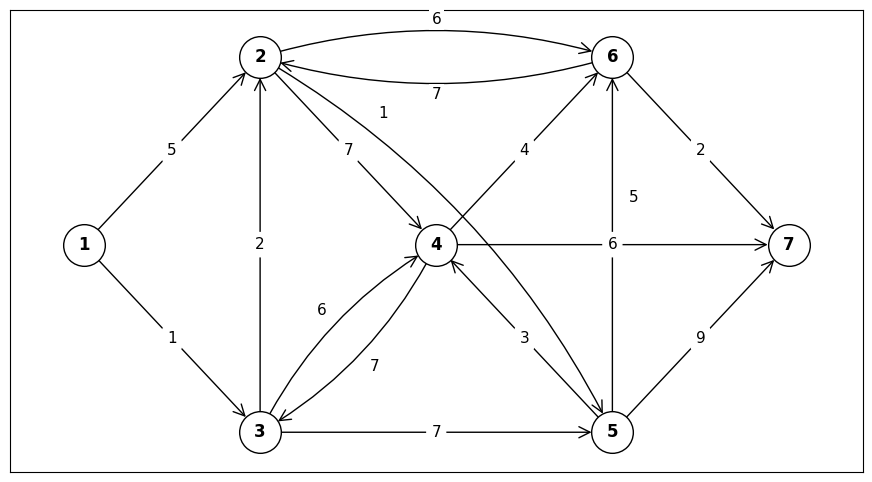

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph() # Para graficar red dirigidas

# dibujar ramas rectas
straight_edges = {
    (1, 2): 5, (1, 3): 1, (3, 2): 2, (3, 5): 7,
    (2, 4): 7, (4, 6): 4, (4, 7): 6, (5, 4): 3, (5, 7): 9,
    (6, 7): 2
}
# dibujar ramas curvas hacia la derecha e izquierda
curved_edges_left = {(6, 2): 7, (4, 3): 7, (2, 5): 1}
curved_edges_right = {(2, 6): 6, (3, 4): 6}

# función de NetworkX que recibe como una lista de tuplas y las agrega a la grafica G
G.add_edge(5, 6)
G.add_edges_from(list(straight_edges.keys()) + list(curved_edges_left.keys()) + list(curved_edges_right.keys()))

#posiciones de los nodos
pos = {1: (0, 1), 2: (1, 2), 3: (1, 0), 4: (2, 1), 5: (3, 0), 6: (3, 2), 7: (4, 1)}
plt.figure(figsize=(11, 6)) #para dibujar los datos

# dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color='white', edgecolors='black', node_size=900)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold') #pone los numeros a los nodos

# dibujar flechas en las ramas
nx.draw_networkx_edges(G, pos, edgelist=list(straight_edges.keys()) + [(5, 6)], arrowstyle='->', arrowsize=20, node_size=900)
nx.draw_networkx_edges(G, pos, edgelist=curved_edges_left.keys(), arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.15', node_size=900)
nx.draw_networkx_edges(G, pos, edgelist=curved_edges_right.keys(), arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.15', node_size=900)

# Para poner las distancias de manera recta
nx.draw_networkx_edge_labels(G, pos, edge_labels=straight_edges, font_size=11, rotate=False)

# distancias de las ramas curvas
custom_labels = {
    (2, 6): (2.0, 2.2),
    (6, 2): (2.0, 1.8),
    (3, 4): (1.35, 0.65),
    (4, 3): (1.65, 0.35),
    (2, 5): (1.7, 1.7),
    (5, 6): (3.12, 1.25)
}

#esta funcion ayuda a poner las distancias en la posicion correcta para que no se encimen
for (u, v), (x, y) in custom_labels.items():
    weight = curved_edges_left.get((u,v)) or curved_edges_right.get((u,v)) or (5 if (u,v) == (5,6) else None)
    plt.text(x, y, str(weight), fontsize=11, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2))
# bbox=dict... pone un fondo blanco atrás del número para que tape la rama y el número se vea bien

plt.show()

**Solución:**

In [ ]:
import networkx as nx

G = nx.Graph() # Para graficar la red no dirigida

# lista de ramas (origen, destino, distancia)
ramas = [
    (1, 2, 5), (1, 3, 1), (3, 2, 2), (3, 4, 6), (4, 3, 7), (3, 5, 7), (2, 4, 7),
    (2, 6, 6), (6, 2, 7), (2, 5, 1), (5, 4, 3), (4, 6, 4), (4, 7, 6), (5, 6, 5),
    (5, 7, 9), (6, 7, 2)
]

G.add_weighted_edges_from(ramas)

#Calcular la ruta más corta
nodo_origen = 1
nodo_destino = 7

ruta_mas_corta = nx.shortest_path(G, source=nodo_origen, target=nodo_destino, weight='weight') #funcion en networkx para dar la ruta como lista de nodos
dis_total = nx.shortest_path_length(G, source=nodo_origen, target=nodo_destino, weight='weight') ##funcion en networkx para dar el valor de la ruta

# imprimir resultados
print(f"Ruta más corta desde {nodo_origen} hasta {nodo_destino}: {ruta_mas_corta}")
print(f"Distancia total: {dis_total}")


Ruta más corta desde 1 hasta 7: [1, 3, 2, 5, 6, 7]
Costo total del recorrido: 11


Por lo tanto la ruta más corta es 1 $\rightarrow$ 3 $\rightarrow$ 2 $\rightarrow$ 5 $\rightarrow$ 6 $\rightarrow$ 7

Distancia total = 11

#<font color= "#d06fed"> 3. *Flujo máximo*

Consideremos una red dirigida con un flujo asociado a cada rama. Se necesita  maximizar el flujo de entrada.

1. Todo flujo a través de una red dirigida se origina en un nodo, el origen y termina en otro, el destino.
2. Los nodos restantes son nodos de transbordo.
3. El flujo a través de un arco es solo en la dirección indicada por la flecha, su cantidad máxima se llama capacidad del arco.
4. El objetivo es maximizar la cantidad total de flujo del origen al destino (la que sale del origen o entra al destino).

**Algoritmo**

1. Identificar una trayectoria de aumento (si no existe una, los flujos netos asignados constituyen un patrón de flujo óptimo).
2. Identificar la capacidad residual $C^*$ de esta trayectoria. Se aumenta en $C^*$ el flujo de esta trayectoria.
3. Se disminuye en $C^*$ la capacidad residual de cada arco de aumento. Se aumenta en $C^*$ la capacidad de cada arco en la dirección opuesta en esta trayectoria.
Regresar al paso 1









**Ejemplo:**

Use la siguiente red para calcular el flujo máximo

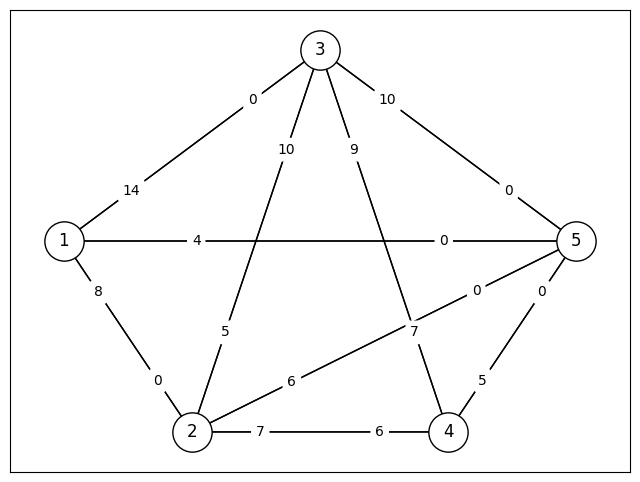

In [29]:
import matplotlib.pyplot as plt
import networkx as nx

# usamos red dirigida para poder poner los valores de la capacidades en cada extremo de los nodos
G = nx.DiGraph()
pos = {1: (-2, 0), 3: (0, 2), 5: (2, 0), 2: (-1, -2), 4: (1, -2)} #posiciones de los nodos

# ponemos las ramas cada una con su valor correspondiente
labels = {
    (1, 3): 14, (3, 1): 0, (1, 5): 4, (5, 1): 0, (1, 2): 8, (2, 1): 0,
    (3, 2): 10, (2, 3): 5, (3, 4): 9, (4, 3): 7, (3, 5): 10, (5, 3): 0,
    (2, 5): 6, (5, 2): 0, (2, 4): 7, (4, 2): 6, (4, 5): 5, (5, 4): 0
}

# añade las ramas a la red
G.add_edges_from(labels.keys())

plt.figure(figsize=(8, 6)) #para dibujar los datos

# dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="white", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=12) #pone los numeros a los nodos

# dibuja la ramas
nx.draw_networkx_edges(G, pos, edge_color="black", arrowstyle="-")


# label_pos=0.25 sirve para poner las capacidades en la misma rama sin que se encimen
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels,
    font_size=10,
    label_pos=0.25,
    rotate=False  # pone los números de manera recta
)

plt.show()



**Solución:**

El flujo máximo es: 25


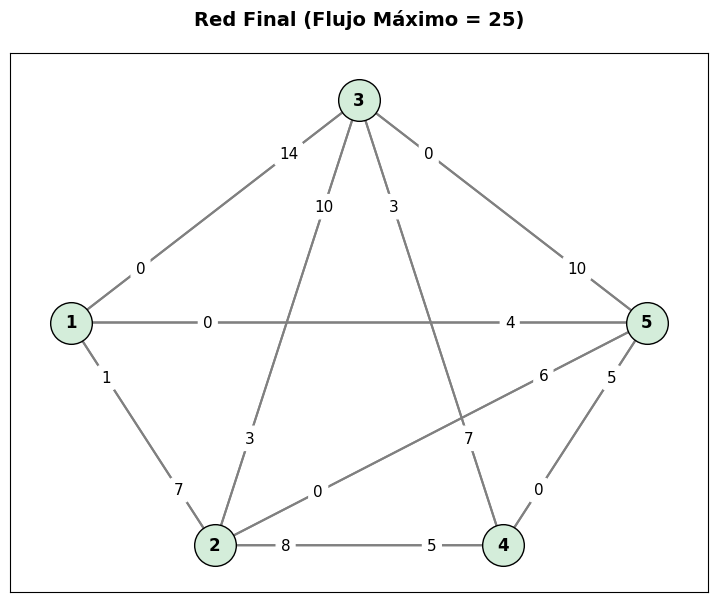

In [30]:
import matplotlib.pyplot as plt
import networkx as nx

# crear red dirigida
G = nx.DiGraph()

edges = [
    (1, 2, 8), (1, 3, 14), (1, 5, 4),
    (2, 3, 5), (2, 4, 7),  (2, 5, 6),
    (3, 2, 10),(3, 4, 9),  (3, 5, 10),
    (4, 2, 6), (4, 3, 7),  (4, 5, 5)
]

for u, v, cap in edges:
    G.add_edge(u, v, capacity=cap)

# funcion en networkx para calcular el flujo máximo
flow_value, flow_dict = nx.maximum_flow(G, 1, 5)
print(f"El flujo máximo es: {flow_value}")

# sirve para calcular las capicidades finales
# ponemos un diccionario con ceros para todas las combinaciones posibles
labels = {}
all_pairs = [
    (1, 3), (3, 1), (1, 5), (5, 1), (1, 2), (2, 1),
    (3, 2), (2, 3), (3, 4), (4, 3), (3, 5), (5, 3),
    (2, 5), (5, 2), (2, 4), (4, 2), (4, 5), (5, 4)
]
for u, v in all_pairs:
    labels[(u, v)] = 0

# llenamos el diccionario
for u, v, cap in edges:
    flujo_enviado = flow_dict[u][v]

    # capacidad de ida: capacidad original menos el flujo que pasó
    labels[(u, v)] = cap - flujo_enviado

    # capacidad de vuelta: se suma el flujo enviado al valor que ya tenia
    labels[(v, u)] += flujo_enviado

# añadir las ramas a la grafica
G_draw = nx.DiGraph()
G_draw.add_edges_from(labels.keys())

pos = {1: (-2, 0), 3: (0, 2), 5: (2, 0), 2: (-1, -2), 4: (1, -2)}

plt.figure(figsize=(9, 7))

# dibujar nodos
nx.draw_networkx_nodes(G_draw, pos, node_size=900, node_color="#d4edda", edgecolors="black")
nx.draw_networkx_labels(G_draw, pos, font_size=12, font_weight="bold")

# dibujar ramas
nx.draw_networkx_edges(G_draw, pos, edge_color="gray", width=1.5, arrowstyle="-")

# label_pos=0.23 sirve para poner las capacidades en la misma rama sin que se encimen
nx.draw_networkx_edge_labels(
    G_draw,
    pos,
    edge_labels=labels,
    font_size=11,
    label_pos=0.23,
    rotate=False     # pone los números de manera recta
)

plt.title(f"Red Final (Flujo Máximo = {flow_value})", fontsize=14, pad=20, fontweight="bold")
plt.show()


Por lo tanto el flujo máximo es 25